In [10]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from collections import defaultdict

In [12]:
def normalize_columns(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df


def auto_find_column(columns, candidates):
    lower_map = {str(c).lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None


def get_column_mapping(df, file_label):
    cols = df.columns.tolist()

    print(f"\nColumns found in {file_label}:")
    print(cols)

    if file_label == "spot file":
        dt_col = auto_find_column(cols, ["datetime", "timestamp", "date_time", "date"])
        spot_col = auto_find_column(cols, ["spot", "close", "price", "ltp"])

        if dt_col is None:
            dt_col = input("Enter datetime column name from spot file: ").strip()
        if spot_col is None:
            spot_col = input("Enter spot/close column name from spot file: ").strip()

        return {
            "datetime": dt_col,
            "spot": spot_col
        }

    elif file_label == "options file":

        dt_col = auto_find_column(cols, ["datetime"])
        expiry_col = auto_find_column(cols, ["expiry"])
        strike_col = auto_find_column(cols, ["strike"])
        type_col = auto_find_column(cols, ["option_type"])
    
        open_col = auto_find_column(cols, ["open"])
        high_col = auto_find_column(cols, ["high"])
        low_col = auto_find_column(cols, ["low"])
        close_col = auto_find_column(cols, ["close"])

    return {
        "datetime": dt_col,
        "expiry": expiry_col,
        "strike": strike_col,
        "option_type": type_col,
        "open": open_col,
        "high": high_col,
        "low": low_col,
        "close": close_col
    }


def standardize_option_type(x):
    s = str(x).strip().upper()
    if s in ["CE", "CALL", "C"]:
        return "CE"
    elif s in ["PE", "PUT", "P"]:
        return "PE"
    return s


def prepare_spot_data(spot_df, mapping):
    df = spot_df.copy()
    df = df.loc[:, ~df.columns.duplicated()].copy()

    df["datetime_std"] = pd.to_datetime(df[mapping["datetime"]], errors="coerce")
    df["spot_std"] = pd.to_numeric(df[mapping["spot"]], errors="coerce")

    df = df.dropna(subset=["datetime_std", "spot_std"]).copy()
    df = df.sort_values("datetime_std").reset_index(drop=True)

    out = df[["datetime_std", "spot_std"]].rename(columns={
        "datetime_std": "datetime",
        "spot_std": "spot"
    })

    return out


def prepare_options_data(options_df, mapping):

    df = options_df.copy()
    df = df.loc[:, ~df.columns.duplicated()].copy()

    df["datetime"] = pd.to_datetime(df[mapping["datetime"]])
    df["expiry"] = pd.to_datetime(df[mapping["expiry"]])
    df["strike"] = pd.to_numeric(df[mapping["strike"]])
    df["option_type"] = df[mapping["option_type"]].apply(standardize_option_type)

    df["open"] = pd.to_numeric(df[mapping["open"]], errors="coerce")
    df["high"] = pd.to_numeric(df[mapping["high"]], errors="coerce")
    df["low"] = pd.to_numeric(df[mapping["low"]], errors="coerce")
    df["close"] = pd.to_numeric(df[mapping["close"]], errors="coerce")

    df = df.dropna(subset=["datetime","expiry","strike","option_type","close"])

    df = df.sort_values(
        ["expiry","strike","option_type","datetime"]
    ).reset_index(drop=True)

    return df[[
        "datetime",
        "expiry",
        "strike",
        "option_type",
        "open",
        "high",
        "low",
        "close"
    ]]


def nearest_strike(spot, step=50):
    return int(round(float(spot) / step) * step)


def build_option_lookup(options_df):
    df = options_df.copy()

    df = df[["datetime", "expiry", "strike", "option_type", "ltp"]].copy()
    df = df.drop_duplicates(
        subset=["datetime", "expiry", "strike", "option_type"],
        keep="last"
    ).copy()

    df = df.sort_values(["expiry", "strike", "option_type", "datetime"]).reset_index(drop=True)

    option_lookup = {}

    for key, grp in df.groupby(["expiry", "strike", "option_type"], sort=False):
        option_lookup[key] = {
            "times": grp["datetime"].to_numpy(),
            "ltps": grp["ltp"].to_numpy(dtype=float)
        }

    available_expiries = sorted(df["expiry"].dropna().unique())

    return option_lookup, available_expiries


def get_next_expiry(current_time, available_expiries):
    current_date = pd.Timestamp(current_time).normalize()

    for exp in available_expiries:
        if pd.Timestamp(exp).normalize() >= current_date:
            return exp

    return None


def get_option_price(option_lookup, expiry, strike, option_type, current_time):
    key = (expiry, strike, option_type)

    if key not in option_lookup:
        return None

    contract_data = option_lookup[key]
    times = contract_data["times"]
    ltps = contract_data["ltps"]

    idx = np.searchsorted(times, np.datetime64(current_time), side="left")

    if idx >= len(times):
        return None

    return float(ltps[idx])


def run_fast_option_backtest(
    spot_df,
    option_lookup,
    available_expiries,
    pe_gap,
    ce_gap,
    stop_loss,
    target,
    pe_symbol_gap=100,
    ce_symbol_gap=100,
    strike_step=50,
    lot_size=50,
    square_off_time_str="15:20",
    max_open_positions=1
):
    if spot_df.empty:
        return pd.DataFrame()

    trades = []
    open_trades = []

    square_off_time = pd.to_datetime(square_off_time_str).time()

    first_spot = float(spot_df.iloc[0]["spot"])
    last_pe_ref = first_spot
    last_ce_ref = first_spot

    for _, row in spot_df.iterrows():
        current_time = row["datetime"]
        current_spot = float(row["spot"])

        signal = None

        if current_spot >= last_pe_ref + pe_gap:
            signal = "PE"
            last_pe_ref = current_spot

        elif current_spot <= last_ce_ref - ce_gap:
            signal = "CE"
            last_ce_ref = current_spot

        # Entry
        if signal is not None and len(open_trades) < max_open_positions:
            atm_strike = nearest_strike(current_spot, strike_step)

            if signal == "PE":
                strike = atm_strike - pe_symbol_gap
            else:
                strike = atm_strike + ce_symbol_gap

            expiry = get_next_expiry(current_time, available_expiries)

            if expiry is not None:
                entry_price = get_option_price(
                    option_lookup=option_lookup,
                    expiry=expiry,
                    strike=strike,
                    option_type=signal,
                    current_time=current_time
                )

                if entry_price is not None:
                    open_trades.append({
                        "entry_time": current_time,
                        "entry_spot": current_spot,
                        "option_type": signal,
                        "strike": strike,
                        "expiry": expiry,
                        "entry_price": entry_price,
                        "sl_price": entry_price + stop_loss,
                        "target_price": entry_price - target
                    })

        # Exit
        remaining_trades = []

        for trade in open_trades:
            current_option_price = get_option_price(
                option_lookup=option_lookup,
                expiry=trade["expiry"],
                strike=trade["strike"],
                option_type=trade["option_type"],
                current_time=current_time
            )

            if current_option_price is None:
                remaining_trades.append(trade)
                continue

            exit_reason = None

            if current_option_price >= trade["sl_price"]:
                exit_reason = "SL"
            elif current_option_price <= trade["target_price"]:
                exit_reason = "TARGET"
            elif pd.Timestamp(current_time).time() >= square_off_time:
                exit_reason = "EOD"

            if exit_reason is not None:
                pnl_points = trade["entry_price"] - current_option_price
                pnl = pnl_points * lot_size

                trades.append({
                    "entry_time": trade["entry_time"],
                    "exit_time": current_time,
                    "entry_spot": trade["entry_spot"],
                    "exit_spot": current_spot,
                    "option_type": trade["option_type"],
                    "strike": trade["strike"],
                    "expiry": trade["expiry"],
                    "entry_price": trade["entry_price"],
                    "exit_price": current_option_price,
                    "exit_reason": exit_reason,
                    "pnl_points": pnl_points,
                    "pnl": pnl
                })
            else:
                remaining_trades.append(trade)

        open_trades = remaining_trades

    return pd.DataFrame(trades)

In [14]:
class SurvivorManagedBacktest:

    def __init__(self, spot_df, config, risk_config):
        self.spot = spot_df.copy()
        self.config = config
        self.risk_config = risk_config

        self.pe_gap = config["pe_gap"]
        self.ce_gap = config["ce_gap"]
        self.pe_symbol_gap = config["pe_symbol_gap"]
        self.ce_symbol_gap = config["ce_symbol_gap"]
        self.pe_quantity = config["pe_quantity"]
        self.ce_quantity = config["ce_quantity"]
        self.pe_reset_gap = config["pe_reset_gap"]
        self.ce_reset_gap = config["ce_reset_gap"]
        self.sell_multiplier_threshold = config["sell_multiplier_threshold"]
        self.min_price_to_sell = config["min_price_to_sell"]

        self.pe_last = None
        self.ce_last = None
        self.pe_reset_gap_flag = 0
        self.ce_reset_gap_flag = 0

        self.open_positions = []
        self.closed_trades = []
        self.skipped = []

        self.strike_step = 50

    def current_open_count(self, current_time):
        return sum(
            1 for pos in self.open_positions
            if pos["status"] == "OPEN" and pos["entry_time"] <= current_time < pos["exit_time"]
        )

    def choose_next_expiry(self, current_time):
        for exp in available_expiries:
            if exp > current_time:
                return exp
        return None

    def find_contract_and_entry(self, current_time, spot_price, option_type, base_gap):
        expiry = self.choose_next_expiry(current_time)
        if expiry is None:
            return None, "No expiry found"

        temp_gap = base_gap

        while temp_gap > 0:
            if option_type == "PE":
                strike = round((spot_price - temp_gap) / self.strike_step) * self.strike_step
            else:
                strike = round((spot_price + temp_gap) / self.strike_step) * self.strike_step

            contract_df = get_contract_df(expiry, strike, option_type)

            if contract_df is None:
                temp_gap -= self.strike_step
                continue

            entry_row = get_first_row_at_or_after(contract_df, current_time)
            if entry_row is None:
                temp_gap -= self.strike_step
                continue

            entry_price = float(entry_row["close"])

            if entry_price < self.min_price_to_sell:
                temp_gap -= self.strike_step
                continue

            return {
                "expiry": expiry,
                "strike": strike,
                "entry_time": pd.Timestamp(entry_row["datetime"]),
                "entry_price": entry_price,
                "contract_df": contract_df,
                "gap_used": temp_gap
            }, None

        return None, "No valid contract found"

    def create_trade(self, current_time, spot_price, option_type, qty, base_gap):
        if self.current_open_count(current_time) >= self.risk_config["max_open_positions"]:
            self.skipped.append({
                "time": current_time,
                "spot_price": spot_price,
                "option_type": option_type,
                "reason": "MAX_OPEN_POSITIONS"
            })
            return

        result, err = self.find_contract_and_entry(current_time, spot_price, option_type, base_gap)

        if result is None:
            self.skipped.append({
                "time": current_time,
                "spot_price": spot_price,
                "option_type": option_type,
                "reason": err
            })
            return

        exit_info = scan_exit_for_short_option(
            contract_df=result["contract_df"],
            entry_dt=result["entry_time"],
            expiry_dt=result["expiry"],
            entry_price=result["entry_price"],
            option_type=option_type,
            target_pct=self.risk_config["target_pct"],
            stop_loss_pct=self.risk_config["stop_loss_pct"]
        )

        if exit_info is None:
            self.skipped.append({
                "time": current_time,
                "spot_price": spot_price,
                "option_type": option_type,
                "reason": "NO_EXIT_FOUND"
            })
            return

        pnl_points = result["entry_price"] - exit_info["exit_price"]
        pnl = pnl_points * qty

        trade = {
            "status": "OPEN",
            "signal_time": current_time,
            "entry_time": result["entry_time"],
            "exit_time": exit_info["exit_time"],
            "spot_entry": spot_price,
            "option_type": option_type,
            "qty": qty,
            "strike": result["strike"],
            "expiry": result["expiry"],
            "gap_used": result["gap_used"],
            "entry_price": result["entry_price"],
            "exit_price": exit_info["exit_price"],
            "exit_reason": exit_info["exit_reason"],
            "pnl": pnl
        }

        trade["status"] = "CLOSED"
        self.open_positions.append(trade)
        self.closed_trades.append(trade)

    def run(self):
        for _, row in self.spot.iterrows():
            current_time = row["datetime"]
            price = float(row["close"])

            if self.pe_last is None:
                self.pe_last = price
                self.ce_last = price
                continue

            # PE side
            if price > self.pe_last:
                price_diff = round(price - self.pe_last, 0)
                if price_diff > self.pe_gap:
                    sell_multiplier = int(price_diff / self.pe_gap)

                    if sell_multiplier <= self.sell_multiplier_threshold:
                        qty = sell_multiplier * self.pe_quantity
                        self.pe_last += self.pe_gap * sell_multiplier

                        self.create_trade(
                            current_time=current_time,
                            spot_price=price,
                            option_type="PE",
                            qty=qty,
                            base_gap=self.pe_symbol_gap
                        )
                        self.pe_reset_gap_flag = 1

            # CE side
            if price < self.ce_last:
                price_diff = round(self.ce_last - price, 0)
                if price_diff > self.ce_gap:
                    sell_multiplier = int(price_diff / self.ce_gap)

                    if sell_multiplier <= self.sell_multiplier_threshold:
                        qty = sell_multiplier * self.ce_quantity
                        self.ce_last -= self.ce_gap * sell_multiplier

                        self.create_trade(
                            current_time=current_time,
                            spot_price=price,
                            option_type="CE",
                            qty=qty,
                            base_gap=self.ce_symbol_gap
                        )
                        self.ce_reset_gap_flag = 1

            # reset references
            if (self.pe_last - price) > self.pe_reset_gap and self.pe_reset_gap_flag:
                self.pe_last = price + self.pe_reset_gap

            if (price - self.ce_last) > self.ce_reset_gap and self.ce_reset_gap_flag:
                self.ce_last = price - self.ce_reset_gap

        trades_df = pd.DataFrame(self.closed_trades)
        skipped_df = pd.DataFrame(self.skipped)

        if not trades_df.empty:
            trades_df = trades_df.sort_values("exit_time").reset_index(drop=True)
            trades_df["cum_pnl"] = trades_df["pnl"].cumsum()

        return trades_df, skipped_df


In [16]:
def get_contract_df(expiry, strike, option_type):
    key = (pd.Timestamp(expiry), float(strike), option_type)
    return option_groups.get(key, None)


def get_first_row_at_or_after(contract_df, dt):
    if contract_df is None or contract_df.empty:
        return None

    rows = contract_df[contract_df["datetime"] >= dt]
    if rows.empty:
        return None
    return rows.iloc[0]


def get_rows_between(contract_df, start_dt, end_dt):
    if contract_df is None or contract_df.empty:
        return pd.DataFrame()

    return contract_df[
        (contract_df["datetime"] >= start_dt) &
        (contract_df["datetime"] <= end_dt)
    ].copy()


def scan_exit_for_short_option(contract_df, entry_dt, expiry_dt, entry_price, option_type, target_pct, stop_loss_pct):
    target_price = entry_price * (1 - target_pct)
    stop_price = entry_price * (1 + stop_loss_pct)

    exit_deadline = pd.Timestamp(expiry_dt).normalize() + pd.Timedelta(hours=15, minutes=25)

    path_df = get_rows_between(contract_df, entry_dt, exit_deadline)

    if path_df.empty:
        return None

    for _, row in path_df.iterrows():
        current_time = row["datetime"]
        current_high = row["high"]
        current_low = row["low"]

        if current_low <= target_price:
            return {
                "exit_time": current_time,
                "exit_price": target_price,
                "exit_reason": "TARGET"
            }

        if current_high >= stop_price:
            return {
                "exit_time": current_time,
                "exit_price": stop_price,
                "exit_reason": "STOPLOSS"
            }

    last_row = path_df.iloc[-1]

    return {
        "exit_time": last_row["datetime"],
        "exit_price": last_row["close"],
        "exit_reason": "EXPIRY_EXIT"
    }

In [18]:
# =========================
# USER INPUTS
# =========================
#spot_file = "spot_data.csv"                 # change if needed
#options_file = "options_data.parquet"       # change if needed
spot_file = "/Users/nathdwar/Python/Algo Trading/nifty50_1min_2024.csv"
options_file = "/Users/nathdwar/Python/Algo Trading/history data/NIFTY_OPTIONS_2024_CONSOLIDATED.parquet"

# Balanced optimized setup
pe_gap =30
ce_gap = 20

# OTM strike distance from ATM
pe_symbol_gap = 100
ce_symbol_gap = 100

stop_loss = 0.5
target = 0.6

lot_size = 50
strike_step = 50
square_off_time_str = "15:20"
max_open_positions = 3
# Optimizer parameters
pe_reset_gap = pe_gap * 2
ce_reset_gap = ce_gap * 2

sell_multiplier_threshold = 3
min_price_to_sell = 5


start_date = ""     # example: "2024-01-01"
end_date = ""       # example: "2024-01-31"



In [20]:
config = {
    "pe_gap": pe_gap,
    "ce_gap": ce_gap,
    "pe_symbol_gap": pe_symbol_gap,
    "ce_symbol_gap": ce_symbol_gap,
    "pe_quantity": 50,
    "ce_quantity": 50,
    "pe_reset_gap": pe_gap * 2,
    "ce_reset_gap": ce_gap * 2,
    "sell_multiplier_threshold": 3,
    "min_price_to_sell": 5
}

risk_config = {
    "target_pct": target,
    "stop_loss_pct": stop_loss,
    "max_open_positions": max_open_positions,
    "lot_size": lot_size
}

In [22]:
# =========================
# LOAD SPOT DATA
# =========================
spot_raw = pd.read_csv(spot_file)
spot_raw = normalize_columns(spot_raw)

spot_mapping = get_column_mapping(spot_raw, "spot file")
spot_df = prepare_spot_data(spot_raw, spot_mapping)



spot_df["datetime"] = pd.to_datetime(spot_df["datetime"])

spot_5m = (
    spot_df.set_index("datetime")
    .resample("5min")
    .agg({"spot": "last"})
    .dropna()
    .reset_index()
    .rename(columns={"spot": "close"})
)

print("\nSpot 5-minute data ready")
print(spot_5m.head())
print("Spot 5m rows:", len(spot_5m))


# Convert to 5-minute bars (optimizer uses 5m data)
spot_df = (
    spot_df.set_index("datetime")
    .resample("5T")
    .last()
    .dropna()
    .reset_index()
)

if start_date:
    spot_df = spot_df[spot_df["datetime"] >= pd.to_datetime(start_date)]

if end_date:
    spot_df = spot_df[
        spot_df["datetime"] <= (
            pd.to_datetime(end_date) + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)
        )
    ]

spot_df["datetime"] = pd.to_datetime(spot_df["datetime"])
spot_df = spot_df.sort_values("datetime").reset_index(drop=True)


print("\nSpot data ready")
print(spot_df.head())
print("Spot rows:", len(spot_df))


# =========================
# LOAD OPTIONS DATA
# =========================
if options_file.endswith(".parquet"):
    options_raw = pd.read_parquet(options_file)
elif options_file.endswith(".csv"):
    options_raw = pd.read_csv(options_file)
else:
    raise ValueError("Options file must be .csv or .parquet")

options_raw = normalize_columns(options_raw)
options_raw["datetime"] = pd.to_datetime(options_raw["datetime"])
options_raw = options_raw.loc[:, ~options_raw.columns.duplicated()].copy()

options_mapping = get_column_mapping(options_raw, "options file")
options_df = prepare_options_data(options_raw, options_mapping)

# Ensure datetime is proper
options_df["datetime"] = pd.to_datetime(options_df["datetime"], errors="coerce")

# Convert likely numeric columns safely
for col in ["open", "high", "low", "close", "ltp", "price", "strike"]:
    if col in options_df.columns:
        options_df[col] = pd.to_numeric(options_df[col], errors="coerce")


print("\nOptions dtypes check:")
print(options_df.dtypes)

        

if start_date:
    options_df = options_df[options_df["datetime"] >= pd.to_datetime(start_date)]

if end_date:
    options_df = options_df[
        options_df["datetime"] <= (
            pd.to_datetime(end_date) + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)
        )
    ]

options_df = options_df.sort_values(["expiry", "strike", "option_type", "datetime"]).reset_index(drop=True)

print("\nOptions data ready")
print(options_df.head())
print("Options rows:", len(options_df))


# =========================
# BUILD OPTION GROUPS
# =========================
option_groups = {
    key: grp.sort_values("datetime").reset_index(drop=True)
    for key, grp in options_df.groupby(["expiry", "strike", "option_type"], sort=False)
}

available_expiries = sorted(options_df["expiry"].dropna().unique())

print("\nManaged option groups ready")
print("Contracts:", len(option_groups))
print("Expiries:", len(available_expiries))




Columns found in spot file:
['date', 'open', 'high', 'low', 'close', 'volume']

Spot 5-minute data ready
             datetime     close
0 2024-01-01 09:15:00  21693.75
1 2024-01-01 09:20:00  21696.55
2 2024-01-01 09:25:00  21700.80
3 2024-01-01 09:30:00  21703.05
4 2024-01-01 09:35:00  21689.70
Spot 5m rows: 18375

Spot data ready
             datetime      spot
0 2024-01-01 09:15:00  21693.75
1 2024-01-01 09:20:00  21696.55
2 2024-01-01 09:25:00  21700.80
3 2024-01-01 09:30:00  21703.05
4 2024-01-01 09:35:00  21689.70
Spot rows: 18375


/var/folders/pr/tnk0dwb55w93vlgsjtqznnq00000gn/T/ipykernel_21116/1225104557.py:31: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  .resample("5T")



Columns found in options file:
['datetime', 'expiry', 'symbol', 'strike', 'option_type', 'open', 'high', 'low', 'close', 'oi', 'volume']

Options dtypes check:
datetime       datetime64[ns]
expiry         datetime64[ns]
strike                  int64
option_type            object
open                  float64
high                  float64
low                   float64
close                 float64
dtype: object

Options data ready
             datetime              expiry  strike option_type     open  \
0 2024-01-01 09:25:00 2024-01-04 15:30:00   18500          CE  3263.05   
1 2024-01-01 09:26:00 2024-01-04 15:30:00   18500          CE  3263.05   
2 2024-01-01 09:27:00 2024-01-04 15:30:00   18500          CE  3263.05   
3 2024-01-01 09:28:00 2024-01-04 15:30:00   18500          CE  3263.05   
4 2024-01-01 09:29:00 2024-01-04 15:30:00   18500          CE  3263.05   

      high      low    close  
0  3263.05  3263.05  3263.05  
1  3263.05  3263.05  3263.05  
2  3263.05  3263.05  3263.0

In [24]:
bt = SurvivorManagedBacktest(
    spot_df=spot_5m,
    config=config,
    risk_config=risk_config
)

tradebook, skipped_trades = bt.run()

In [26]:
print(options_raw.columns.tolist())

['datetime', 'expiry', 'symbol', 'strike', 'option_type', 'open', 'high', 'low', 'close', 'oi', 'volume']


In [28]:
print("\nTradebook preview")
print(tradebook.head())

print("\nSkipped preview")
print(skipped_trades.head())

print("\nTotal Trades:", len(tradebook))
print("Skipped Signals:", len(skipped_trades))

if not tradebook.empty:
    print("Total P&L:", tradebook["pnl"].sum())
    print("Win Rate:", (tradebook["pnl"] > 0).mean() * 100)
else:
    print("Total P&L: 0")
    print("Win Rate: 0")


Tradebook preview
   status         signal_time          entry_time           exit_time  \
0  CLOSED 2024-01-01 09:50:00 2024-01-01 09:50:00 2024-01-01 14:42:00   
1  CLOSED 2024-01-01 14:40:00 2024-01-01 14:40:00 2024-01-01 15:20:00   
2  CLOSED 2024-01-01 14:10:00 2024-01-01 14:10:00 2024-01-01 15:21:00   
3  CLOSED 2024-01-01 13:45:00 2024-01-01 13:45:00 2024-01-02 09:57:00   
4  CLOSED 2024-01-02 09:55:00 2024-01-02 09:55:00 2024-01-03 09:15:00   

   spot_entry option_type  qty  strike              expiry  gap_used  \
0    21731.45          PE   50   21650 2024-01-04 15:30:00       100   
1    21817.30          PE   50   21700 2024-01-04 15:30:00       100   
2    21792.65          PE   50   21700 2024-01-04 15:30:00       100   
3    21754.80          PE   50   21650 2024-01-04 15:30:00       100   
4    21636.80          CE  100   21750 2024-01-04 15:30:00       100   

   entry_price  exit_price exit_reason      pnl  cum_pnl  
0        75.20      30.080      TARGET  2256.00  2

In [31]:
# Sort tradebook by exit time
if "exit_time" in tradebook.columns:
    tradebook["exit_time"] = pd.to_datetime(tradebook["exit_time"], errors="coerce")
    tradebook = tradebook.sort_values("exit_time").reset_index(drop=True)

print("\nTradebook after sorting:")
print(tradebook.head())


Tradebook after sorting:
   status         signal_time          entry_time           exit_time  \
0  CLOSED 2024-01-01 09:50:00 2024-01-01 09:50:00 2024-01-01 14:42:00   
1  CLOSED 2024-01-01 14:40:00 2024-01-01 14:40:00 2024-01-01 15:20:00   
2  CLOSED 2024-01-01 14:10:00 2024-01-01 14:10:00 2024-01-01 15:21:00   
3  CLOSED 2024-01-01 13:45:00 2024-01-01 13:45:00 2024-01-02 09:57:00   
4  CLOSED 2024-01-02 09:55:00 2024-01-02 09:55:00 2024-01-03 09:15:00   

   spot_entry option_type  qty  strike              expiry  gap_used  \
0    21731.45          PE   50   21650 2024-01-04 15:30:00       100   
1    21817.30          PE   50   21700 2024-01-04 15:30:00       100   
2    21792.65          PE   50   21700 2024-01-04 15:30:00       100   
3    21754.80          PE   50   21650 2024-01-04 15:30:00       100   
4    21636.80          CE  100   21750 2024-01-04 15:30:00       100   

   entry_price  exit_price exit_reason      pnl  cum_pnl  
0        75.20      30.080      TARGET  225

In [33]:
print("User notebook trades:", len(tradebook))
print("User notebook pnl:", tradebook["pnl"].sum())


print("spot_5m rows:", len(spot_5m))
print("spot_5m min:", spot_5m["datetime"].min())
print("spot_5m max:", spot_5m["datetime"].max())

print(options_df.columns.tolist())

User notebook trades: 863
User notebook pnl: 531858.5
spot_5m rows: 18375
spot_5m min: 2024-01-01 09:15:00
spot_5m max: 2024-12-31 15:25:00
['datetime', 'expiry', 'strike', 'option_type', 'open', 'high', 'low', 'close']


In [37]:
# =========================
# BASIC SUMMARY
# =========================

capital = 200000   # assumed trading capital (change if needed)

if tradebook.empty:
    print("No trades found.")
else:
    total_pnl = tradebook["pnl"].sum()
    total_trades = len(tradebook)

    winning_trades = (tradebook["pnl"] > 0).sum()
    losing_trades = (tradebook["pnl"] < 0).sum()

    win_rate = (winning_trades / total_trades) * 100 if total_trades > 0 else 0
    avg_pnl = tradebook["pnl"].mean()

    max_profit = tradebook["pnl"].max()
    max_loss = tradebook["pnl"].min()

    pnl_percent = (total_pnl / capital) * 100

    print("=========== BACKTEST SUMMARY ===========")

    print(f"Capital Used   : ₹{capital:,.0f}")
    print(f"Total P&L      : ₹{total_pnl:,.2f}")
    print(f"P&L %          : {pnl_percent:.2f}%")

    print(f"Total Trades   : {total_trades}")
    print(f"Winning Trades : {winning_trades}")
    print(f"Losing Trades  : {losing_trades}")
    print(f"Win Rate       : {win_rate:.2f}%")

    print(f"Average P&L    : ₹{avg_pnl:,.2f}")
    print(f"Max Profit     : ₹{max_profit:,.2f}")
    print(f"Max Loss       : ₹{max_loss:,.2f}")

=========== BACKTEST SUMMARY ===========
Capital Used   : ₹200,000
Total P&L      : ₹531,858.50
P&L %          : 265.93%
Total Trades   : 863
Winning Trades : 512
Losing Trades  : 349
Win Rate       : 59.33%
Average P&L    : ₹616.29
Max Profit     : ₹25,605.00
Max Loss       : ₹-32,336.25


In [39]:
# =========================
# PREPARE TRADEBOOK FOR CHARTS
# =========================

if not tradebook.empty:
    tradebook["entry_time"] = pd.to_datetime(tradebook["entry_time"])
    tradebook["exit_time"] = pd.to_datetime(tradebook["exit_time"])

    # Sort by exit time
    tradebook = tradebook.sort_values("exit_time").reset_index(drop=True)

    # Trade number
    tradebook["trade_no"] = np.arange(1, len(tradebook) + 1)

    # Cumulative P&L
    tradebook["cum_pnl"] = tradebook["pnl"].cumsum()

    # Exit date
    tradebook["exit_date"] = tradebook["exit_time"].dt.date

    print(tradebook.head())

   status         signal_time          entry_time           exit_time  \
0  CLOSED 2024-01-01 09:50:00 2024-01-01 09:50:00 2024-01-01 14:42:00   
1  CLOSED 2024-01-01 14:40:00 2024-01-01 14:40:00 2024-01-01 15:20:00   
2  CLOSED 2024-01-01 14:10:00 2024-01-01 14:10:00 2024-01-01 15:21:00   
3  CLOSED 2024-01-01 13:45:00 2024-01-01 13:45:00 2024-01-02 09:57:00   
4  CLOSED 2024-01-02 09:55:00 2024-01-02 09:55:00 2024-01-03 09:15:00   

   spot_entry option_type  qty  strike              expiry  gap_used  \
0    21731.45          PE   50   21650 2024-01-04 15:30:00       100   
1    21817.30          PE   50   21700 2024-01-04 15:30:00       100   
2    21792.65          PE   50   21700 2024-01-04 15:30:00       100   
3    21754.80          PE   50   21650 2024-01-04 15:30:00       100   
4    21636.80          CE  100   21750 2024-01-04 15:30:00       100   

   entry_price  exit_price exit_reason      pnl  cum_pnl  trade_no   exit_date  
0        75.20      30.080      TARGET  2256.00

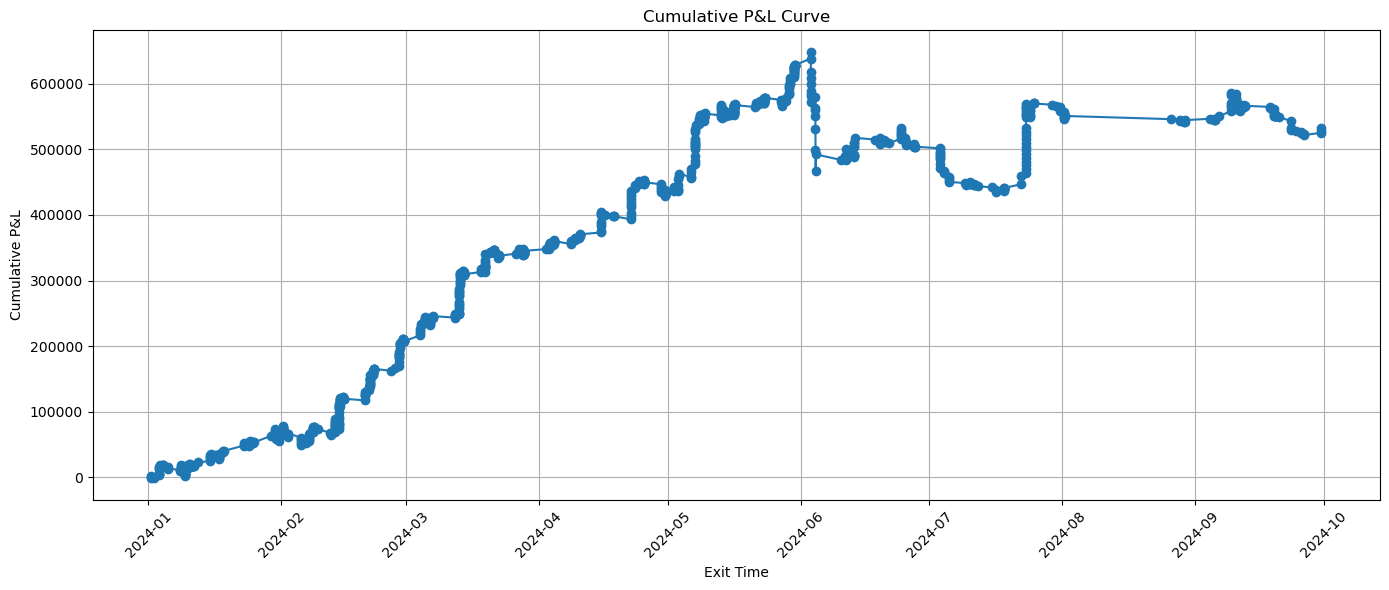

In [41]:
# =========================
# CUMULATIVE P&L CURVE
# =========================

import matplotlib.pyplot as plt

if not tradebook.empty:
    plt.figure(figsize=(14, 6))
    plt.plot(tradebook["exit_time"], tradebook["cum_pnl"], marker="o")
    plt.title("Cumulative P&L Curve")
    plt.xlabel("Exit Time")
    plt.ylabel("Cumulative P&L")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

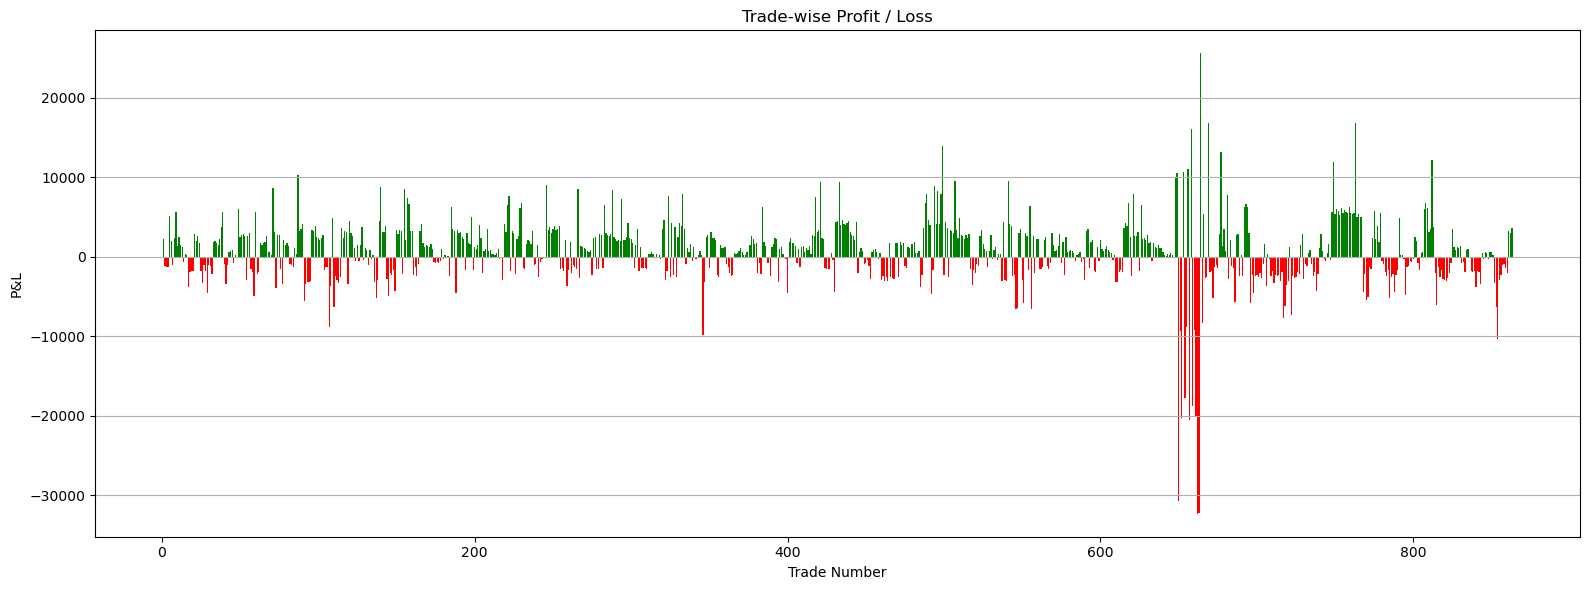

In [43]:
# =========================
# TRADE-WISE P&L BAR CHART
# =========================

if not tradebook.empty:
    plt.figure(figsize=(16, 6))

    colors = ["green" if x > 0 else "red" for x in tradebook["pnl"]]

    plt.bar(tradebook["trade_no"], tradebook["pnl"], color=colors)
    plt.title("Trade-wise Profit / Loss")
    plt.xlabel("Trade Number")
    plt.ylabel("P&L")
    plt.grid(True, axis="y")
    plt.tight_layout()
    plt.show()

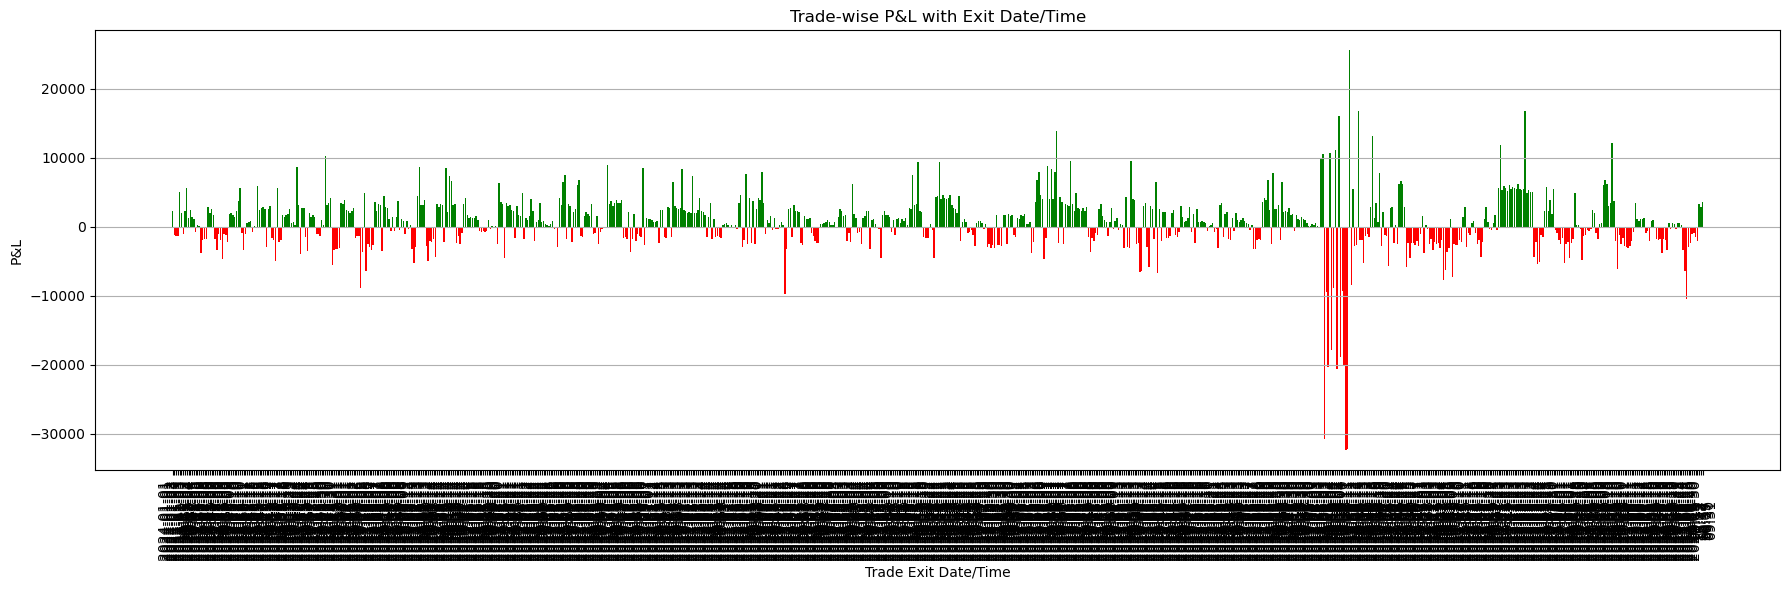

In [45]:
# =========================
# TRADE P&L BY EXIT DATE/TIME
# =========================

if not tradebook.empty:
    labels = tradebook["exit_time"].dt.strftime("%Y-%m-%d\n%H:%M")

    plt.figure(figsize=(18, 6))
    colors = ["green" if x > 0 else "red" for x in tradebook["pnl"]]

    plt.bar(range(len(tradebook)), tradebook["pnl"], color=colors)
    plt.xticks(range(len(tradebook)), labels, rotation=90)
    plt.title("Trade-wise P&L with Exit Date/Time")
    plt.xlabel("Trade Exit Date/Time")
    plt.ylabel("P&L")
    plt.grid(True, axis="y")
    plt.tight_layout()
    plt.show()

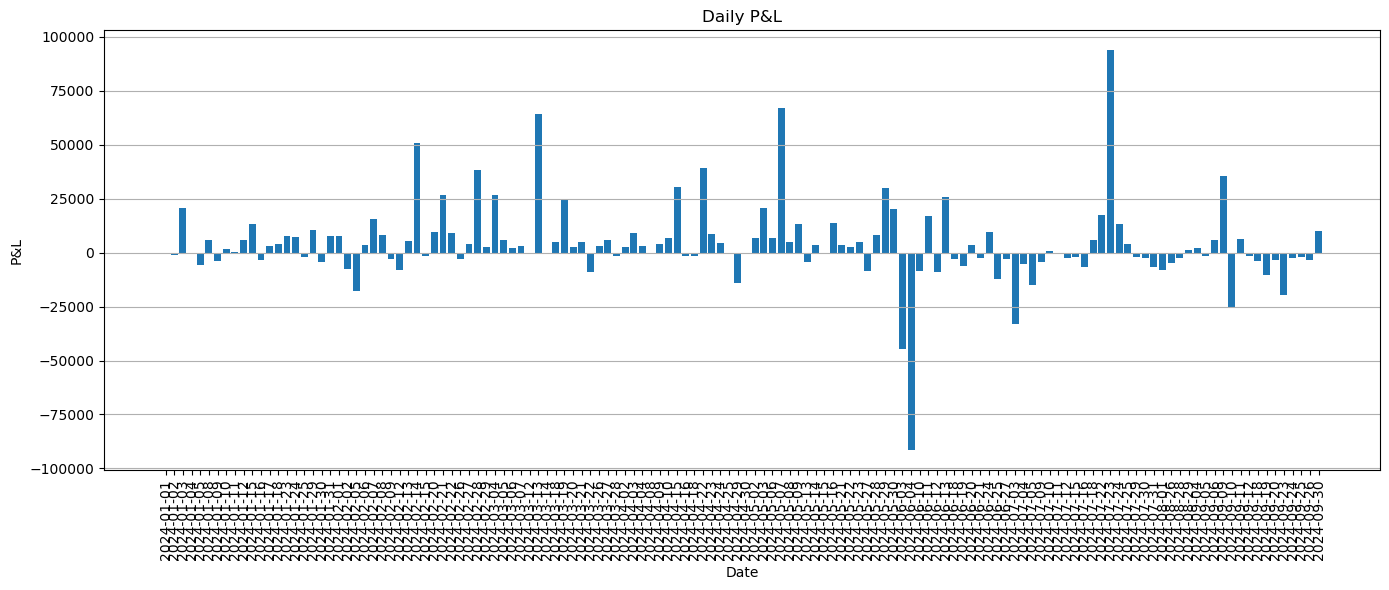

    exit_date       pnl   cum_pnl
0  2024-01-01   -202.75   -202.75
1  2024-01-02  -1331.25  -1534.00
2  2024-01-03  20552.25  19018.25
3  2024-01-04   -140.00  18878.25
4  2024-01-05  -5676.25  13202.00


In [47]:
# =========================
# DAILY P&L
# =========================

if not tradebook.empty:
    daily_pnl = tradebook.groupby("exit_date", as_index=False)["pnl"].sum()
    daily_pnl["cum_pnl"] = daily_pnl["pnl"].cumsum()

    plt.figure(figsize=(14, 6))
    plt.bar(daily_pnl["exit_date"].astype(str), daily_pnl["pnl"])
    plt.title("Daily P&L")
    plt.xlabel("Date")
    plt.ylabel("P&L")
    plt.xticks(rotation=90)
    plt.grid(True, axis="y")
    plt.tight_layout()
    plt.show()

    print(daily_pnl.head())

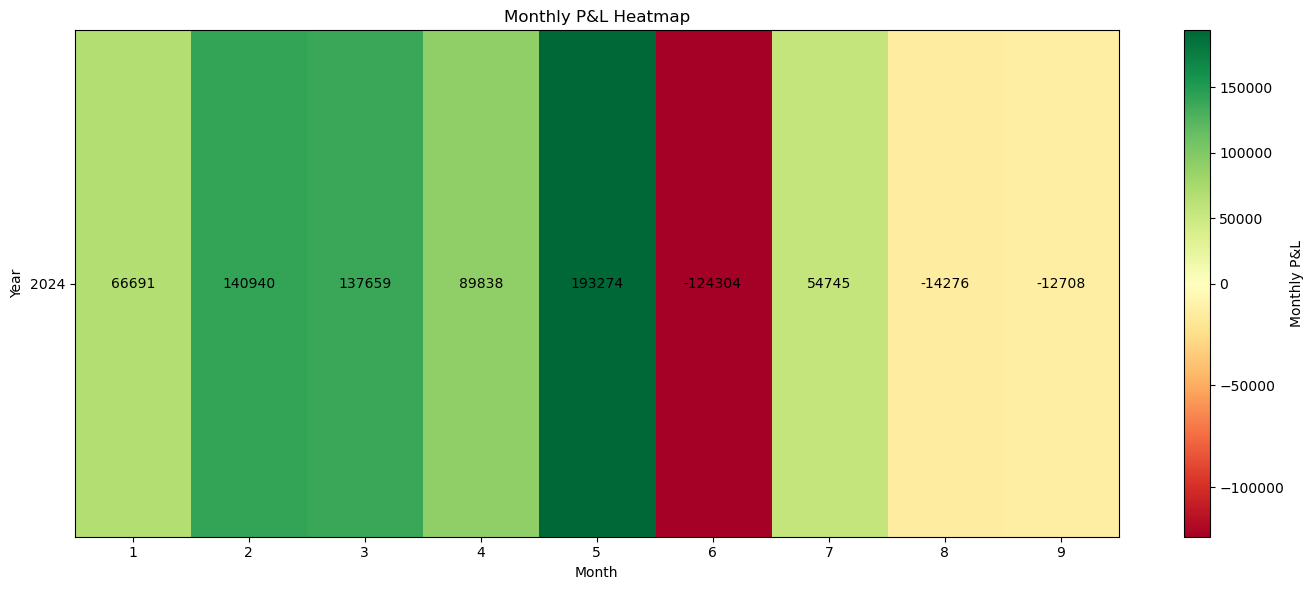

month         1          2         3        4         5         6        7  \
year                                                                         
2024   66690.75  140939.75  137659.0  89838.0  193274.0 -124304.5  54745.0   

month        8        9  
year                     
2024  -14276.0 -12707.5  


In [57]:
# =========================
# MONTHLY HEATMAP (RED LOSS / GREEN PROFIT)
# =========================

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

if not tradebook.empty:

    tradebook["year"] = tradebook["exit_time"].dt.year
    tradebook["month"] = tradebook["exit_time"].dt.month

    monthly_pnl = tradebook.groupby(["year", "month"])["pnl"].sum().reset_index()

    heatmap_df = monthly_pnl.pivot(index="year", columns="month", values="pnl").fillna(0)

    plt.figure(figsize=(14,6))

    # Color scale centered at 0
    norm = mcolors.TwoSlopeNorm(
        vmin=heatmap_df.values.min(),
        vcenter=0,
        vmax=heatmap_df.values.max()
    )

    im = plt.imshow(
        heatmap_df,
        aspect="auto",
        cmap="RdYlGn",
        norm=norm
    )

    plt.colorbar(im, label="Monthly P&L")

    plt.title("Monthly P&L Heatmap")
    plt.xlabel("Month")
    plt.ylabel("Year")

    plt.xticks(
        ticks=np.arange(len(heatmap_df.columns)),
        labels=heatmap_df.columns
    )

    plt.yticks(
        ticks=np.arange(len(heatmap_df.index)),
        labels=heatmap_df.index
    )

    # Write numbers in cells
    for i in range(len(heatmap_df.index)):
        for j in range(len(heatmap_df.columns)):
            val = heatmap_df.iloc[i, j]
            plt.text(j, i, f"{val:.0f}", ha="center", va="center", color="black")

    plt.tight_layout()
    plt.show()

    print(heatmap_df)

In [59]:
# =========================
# EXPORT FINAL TRADEBOOK
# =========================

if not tradebook.empty:
    tradebook.to_csv("tradebook_with_analytics.csv", index=False)
    print("Saved: tradebook_with_analytics.csv")

Saved: tradebook_with_analytics.csv


In [61]:
tradebook.to_csv("survivor_strategy_tradebook.csv", index=False)

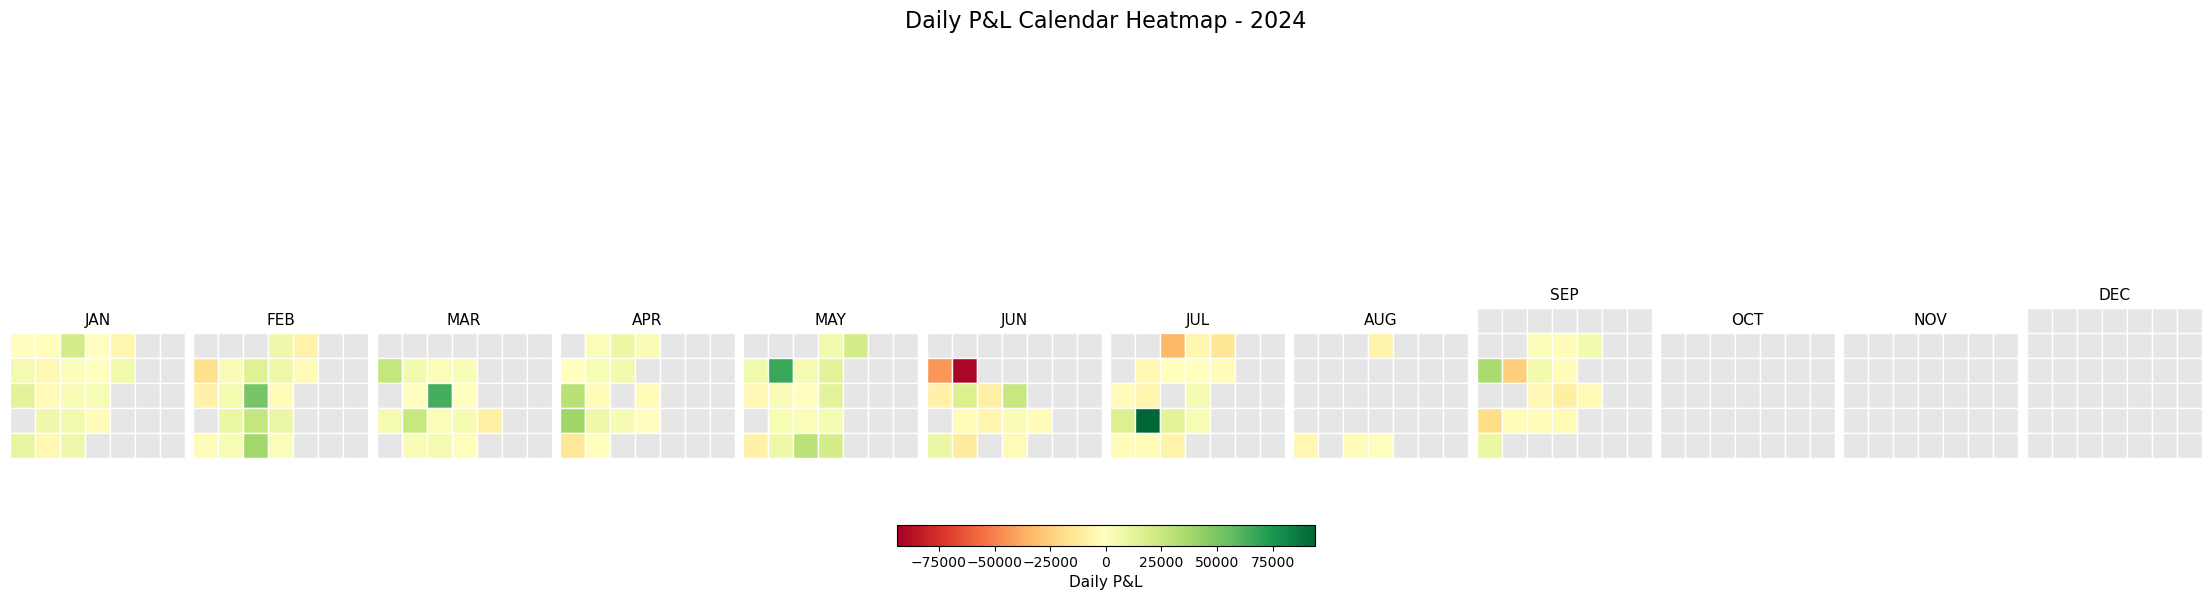

In [65]:
# =========================
# DAILY CALENDAR HEATMAP (Improved)
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import calendar

if not tradebook.empty:

    tb = tradebook.copy()
    tb["exit_time"] = pd.to_datetime(tb["exit_time"])
    tb["date"] = tb["exit_time"].dt.date

    daily_pnl = tb.groupby("date", as_index=False)["pnl"].sum()
    daily_pnl["date"] = pd.to_datetime(daily_pnl["date"])

    year = daily_pnl["date"].dt.year.iloc[0]
    daily_pnl = daily_pnl[daily_pnl["date"].dt.year == year]

    pnl_map = dict(zip(daily_pnl["date"].dt.date, daily_pnl["pnl"]))

    max_abs = max(abs(daily_pnl["pnl"].min()), abs(daily_pnl["pnl"].max()))
    if max_abs == 0:
        max_abs = 1

    cmap = plt.cm.RdYlGn
    norm = plt.Normalize(vmin=-max_abs, vmax=max_abs)

    # Bigger figure height
    fig, axes = plt.subplots(
        1, 12,
        figsize=(22, 6),
        constrained_layout=True
    )

    fig.suptitle(f"Daily P&L Calendar Heatmap - {year}", fontsize=16)

    month_names = ["JAN","FEB","MAR","APR","MAY","JUN",
                   "JUL","AUG","SEP","OCT","NOV","DEC"]

    for month in range(1, 13):

        ax = axes[month-1]
        ax.set_title(month_names[month-1], fontsize=11)

        month_cal = calendar.monthcalendar(year, month)

        for week_idx, week in enumerate(month_cal):
            for day_idx, day in enumerate(week):

                x = day_idx
                y = week_idx

                if day == 0:
                    color = "#e6e6e6"
                else:
                    current_date = pd.Timestamp(year=year, month=month, day=day).date()
                    pnl = pnl_map.get(current_date, np.nan)

                    if pd.isna(pnl):
                        color = "#e6e6e6"
                    else:
                        color = cmap(norm(pnl))

                rect = patches.Rectangle(
                    (x, y), 1, 1,
                    facecolor=color,
                    edgecolor="white",
                    linewidth=1
                )

                ax.add_patch(rect)

        ax.set_xlim(0,7)
        ax.set_ylim(len(month_cal),0)
        ax.set_aspect("equal")
        ax.axis("off")

    # Better positioned colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes,
        orientation="horizontal",
        fraction=0.05,
        pad=0.15
    )

    cbar.set_label("Daily P&L", fontsize=11)

    plt.show()


===== VALIDATION CHECK =====
Total rows in tradebook for selected year: 863
Total unique trading dates in selected year: 134
Total P&L from tradebook for selected year: 531858.5
Total P&L from daily aggregation: 531858.5

Top 20 daily P&L rows:
      date  trade_count  daily_pnl
2024-01-01            3    -202.75
2024-01-02            1   -1331.25
2024-01-03            9   20552.25
2024-01-04            3    -140.00
2024-01-05            2   -5676.25
2024-01-08            6    5713.00
2024-01-09           14   -3874.00
2024-01-10            6    1677.25
2024-01-11            4      67.00
2024-01-12            1    5958.00
2024-01-15            7   13461.50
2024-01-16            2   -3423.75
2024-01-17            8    3288.50
2024-01-18            4    4080.00
2024-01-23            3    7871.25
2024-01-24            8    7188.75
2024-01-25            5   -1904.00
2024-01-29            1   10287.00
2024-01-30            7   -4473.25
2024-01-31            4    7571.50

Largest profit day

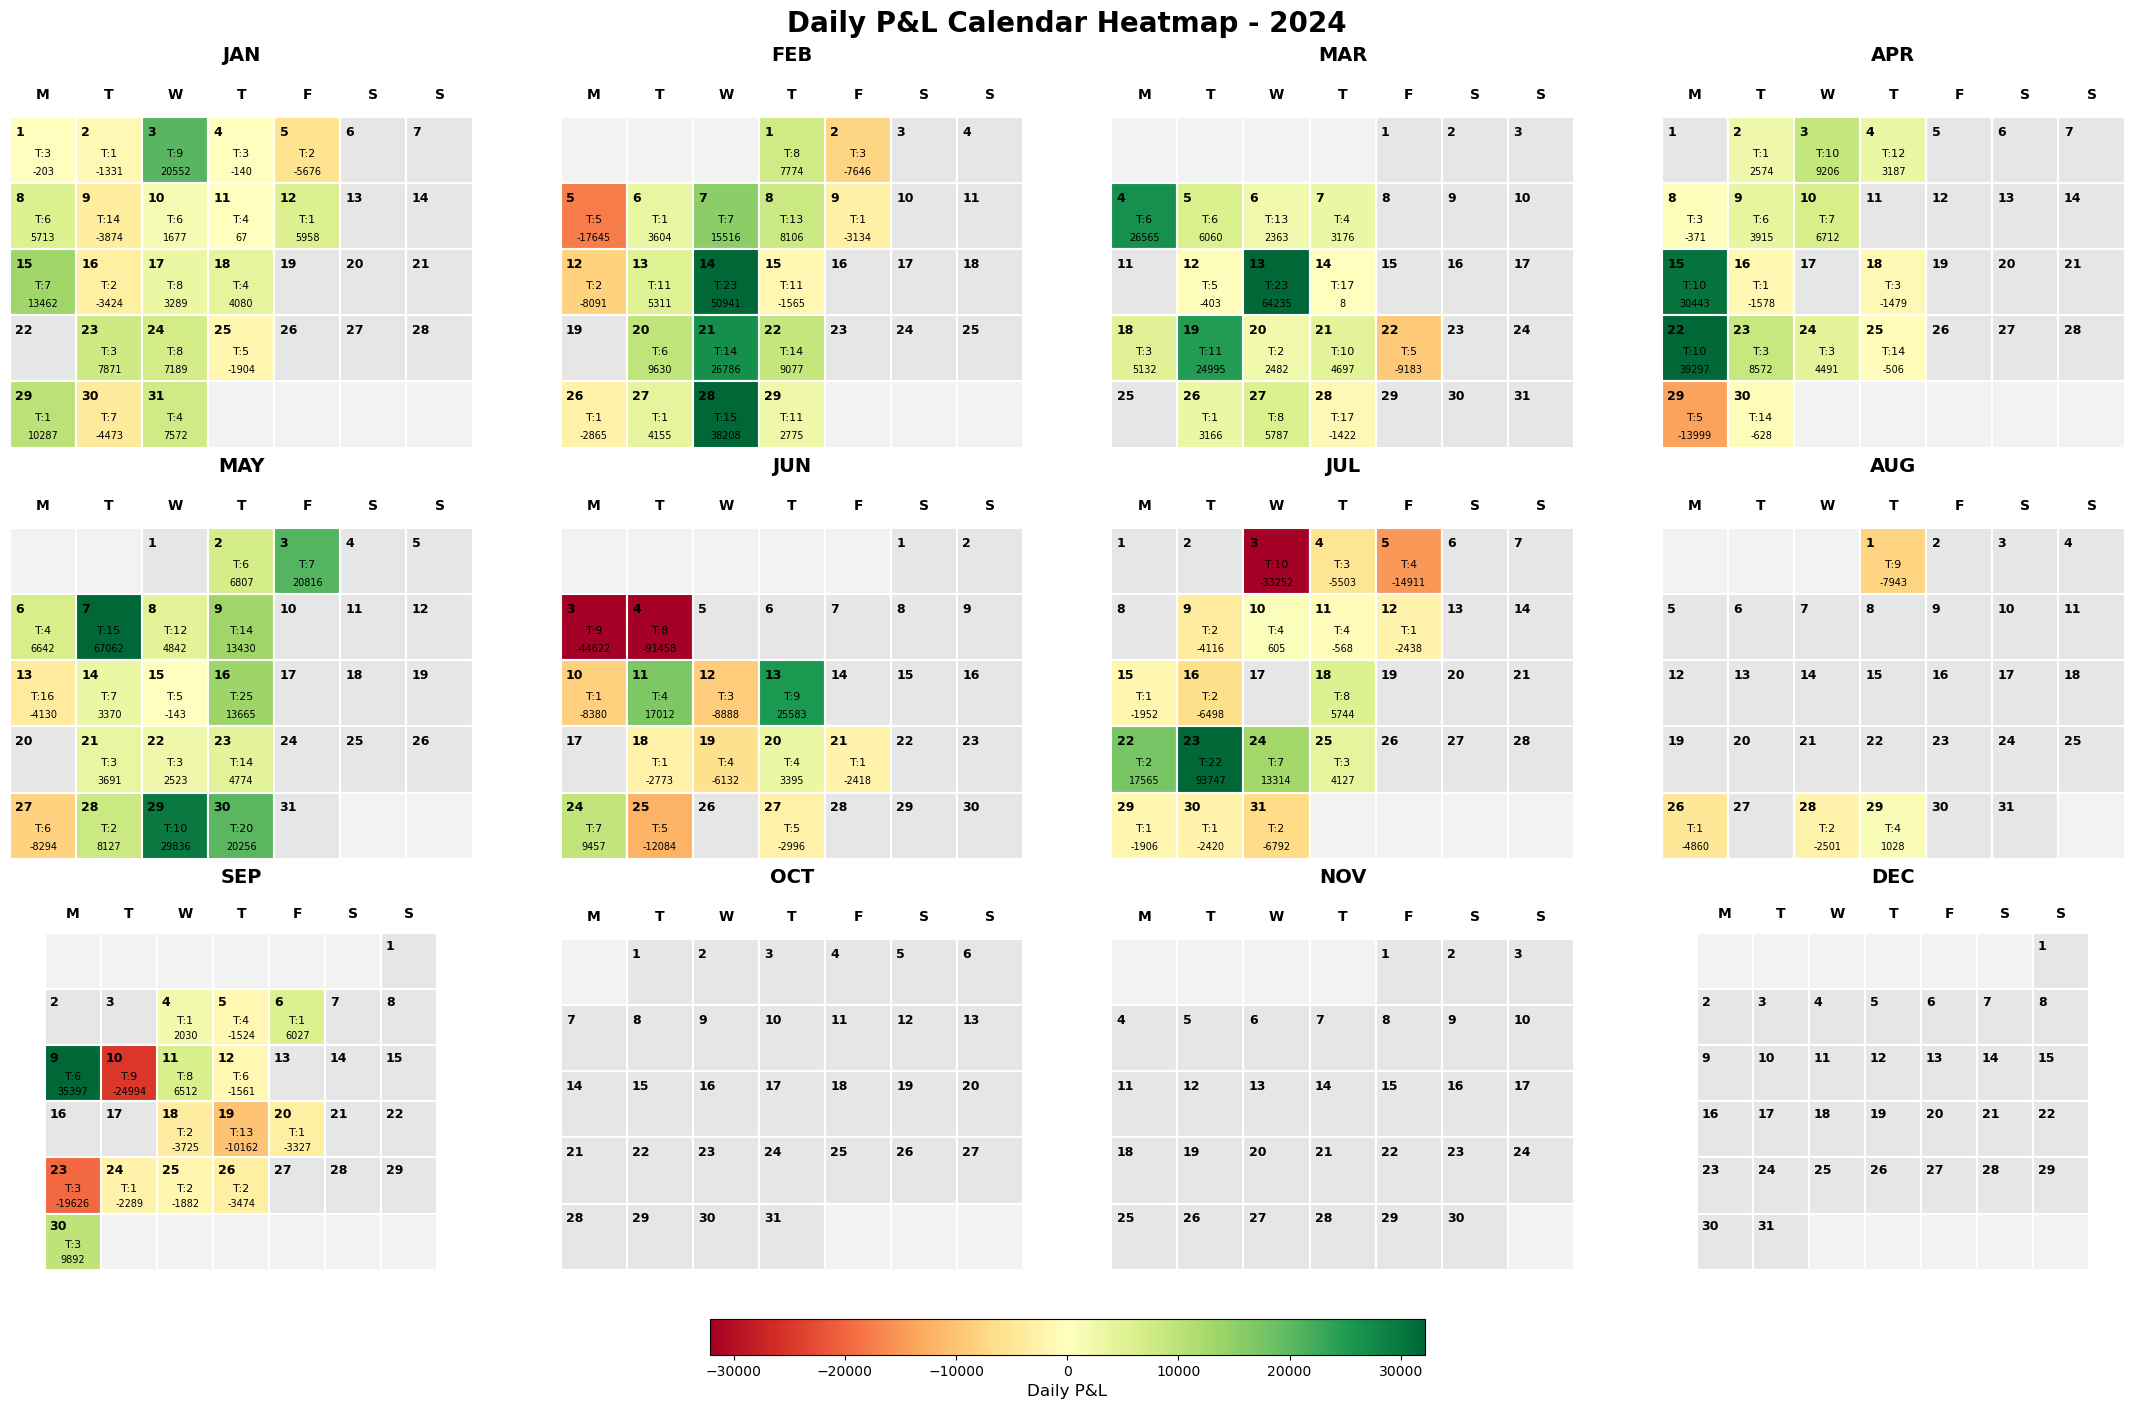

In [67]:
# =========================
# DAILY CALENDAR HEATMAP (ZOOMED + VALIDATION)
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import calendar
from matplotlib import colors

if not tradebook.empty:

    # -------------------------
    # 1. PREPARE DATA
    # -------------------------
    tb = tradebook.copy()
    tb["exit_time"] = pd.to_datetime(tb["exit_time"])
    tb["date"] = tb["exit_time"].dt.floor("D")

    # Daily aggregation
    daily_summary = (
        tb.groupby("date")
          .agg(
              daily_pnl=("pnl", "sum"),
              trade_count=("pnl", "size"),
              avg_pnl=("pnl", "mean")
          )
          .reset_index()
    )

    # pick one year
    years = sorted(daily_summary["date"].dt.year.unique())
    if len(years) != 1:
        print("Multiple years found:", years)
        print("Using first year only:", years[0])

    year = years[0]
    daily_summary = daily_summary[daily_summary["date"].dt.year == year].copy()

    # Keep lookup maps
    pnl_map = dict(zip(daily_summary["date"].dt.date, daily_summary["daily_pnl"]))
    count_map = dict(zip(daily_summary["date"].dt.date, daily_summary["trade_count"]))

    # -------------------------
    # 2. VALIDATION CHECKS
    # -------------------------
    print("\n===== VALIDATION CHECK =====")
    print("Total rows in tradebook for selected year:",
          len(tb[tb["date"].dt.year == year]))
    print("Total unique trading dates in selected year:",
          daily_summary["date"].nunique())
    print("Total P&L from tradebook for selected year:",
          round(tb.loc[tb["date"].dt.year == year, "pnl"].sum(), 2))
    print("Total P&L from daily aggregation:",
          round(daily_summary["daily_pnl"].sum(), 2))

    print("\nTop 20 daily P&L rows:")
    print(
        daily_summary.sort_values("date")[["date", "trade_count", "daily_pnl"]]
        .head(20)
        .to_string(index=False)
    )

    print("\nLargest profit days:")
    print(
        daily_summary.sort_values("daily_pnl", ascending=False)[["date", "trade_count", "daily_pnl"]]
        .head(10)
        .to_string(index=False)
    )

    print("\nLargest loss days:")
    print(
        daily_summary.sort_values("daily_pnl", ascending=True)[["date", "trade_count", "daily_pnl"]]
        .head(10)
        .to_string(index=False)
    )

    # -------------------------
    # 3. COLOR SCALE
    # -------------------------
    # Robust scale so 1 huge day does not wash out all others
    q_low = daily_summary["daily_pnl"].quantile(0.05)
    q_high = daily_summary["daily_pnl"].quantile(0.95)
    max_abs = max(abs(q_low), abs(q_high))
    if max_abs == 0 or np.isnan(max_abs):
        max_abs = max(abs(daily_summary["daily_pnl"].min()), abs(daily_summary["daily_pnl"].max()))
    if max_abs == 0 or np.isnan(max_abs):
        max_abs = 1

    cmap = plt.cm.RdYlGn
    norm = colors.TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)

    # -------------------------
    # 4. PLOT - ZOOMED LAYOUT
    # -------------------------
    fig, axes = plt.subplots(3, 4, figsize=(22, 14), constrained_layout=True)
    axes = axes.flatten()

    fig.suptitle(f"Daily P&L Calendar Heatmap - {year}", fontsize=20, fontweight="bold")

    month_names = ["JAN", "FEB", "MAR", "APR", "MAY", "JUN",
                   "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"]

    for month in range(1, 13):
        ax = axes[month - 1]
        ax.set_title(month_names[month - 1], fontsize=14, pad=12, fontweight="bold")

        month_cal = calendar.monthcalendar(year, month)

        for week_idx, week in enumerate(month_cal):
            for day_idx, day in enumerate(week):
                x = day_idx
                y = week_idx

                # empty calendar slot
                if day == 0:
                    rect = patches.Rectangle(
                        (x, y), 1, 1,
                        facecolor="#f2f2f2",
                        edgecolor="white",
                        linewidth=1.5
                    )
                    ax.add_patch(rect)
                    continue

                current_date = pd.Timestamp(year=year, month=month, day=day).date()
                pnl_value = pnl_map.get(current_date, np.nan)
                trade_count = count_map.get(current_date, 0)

                if pd.isna(pnl_value):
                    facecolor = "#e6e6e6"
                else:
                    facecolor = cmap(norm(pnl_value))

                rect = patches.Rectangle(
                    (x, y), 1, 1,
                    facecolor=facecolor,
                    edgecolor="white",
                    linewidth=1.5
                )
                ax.add_patch(rect)

                # day number
                ax.text(
                    x + 0.08, y + 0.22, str(day),
                    ha="left", va="center",
                    fontsize=9, color="black", fontweight="bold"
                )

                # trade count
                if trade_count > 0:
                    ax.text(
                        x + 0.5, y + 0.55, f"T:{trade_count}",
                        ha="center", va="center",
                        fontsize=8, color="black"
                    )

                    # daily pnl
                    ax.text(
                        x + 0.5, y + 0.82, f"{pnl_value:.0f}",
                        ha="center", va="center",
                        fontsize=7, color="black"
                    )

        # weekday headers
        weekday_labels = ["M", "T", "W", "T", "F", "S", "S"]
        for i, lab in enumerate(weekday_labels):
            ax.text(i + 0.5, -0.35, lab, ha="center", va="center",
                    fontsize=10, fontweight="bold")

        ax.set_xlim(0, 7)
        ax.set_ylim(len(month_cal), -0.6)
        ax.set_aspect("equal")
        ax.axis("off")

    # -------------------------
    # 5. COLORBAR
    # -------------------------
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes,
        orientation="horizontal",
        fraction=0.03,
        pad=0.04
    )
    cbar.set_label("Daily P&L", fontsize=12)

    plt.show()

In [69]:
tb2 = tb.dropna(subset=["exit_time"]).copy()
tb2["year_month"] = tb2["exit_time"].dt.to_period("M")

monthly_check = (
    tb2.groupby("year_month")
       .agg(
           trades=("pnl", "size"),
           pnl=("pnl", "sum")
       )
       .reset_index()
)

print(monthly_check.to_string(index=False))

year_month  trades        pnl
   2024-01      98   66690.75
   2024-02     147  140939.75
   2024-03     131  137659.00
   2024-04     102   89838.00
   2024-05     169  193274.00
   2024-06      61 -124304.50
   2024-07      77   54745.00
   2024-08      16  -14276.00
   2024-09      62  -12707.50


In [71]:
tb = tradebook.copy()
tb["entry_time"] = pd.to_datetime(tb["entry_time"], errors="coerce")
tb["exit_time"] = pd.to_datetime(tb["exit_time"], errors="coerce")

print("========== DATE COVERAGE ==========")
print("Entry min:", tb["entry_time"].min())
print("Entry max:", tb["entry_time"].max())
print("Exit min :", tb["exit_time"].min())
print("Exit max :", tb["exit_time"].max())

print("\n========== EXIT YEAR COUNTS ==========")
print(tb["exit_time"].dropna().dt.year.value_counts().sort_index())

print("\n========== MONTHLY EXIT TRADE COUNTS ==========")
tmp = tb.dropna(subset=["exit_time"]).copy()
tmp["month"] = tmp["exit_time"].dt.month
tmp["month_name"] = tmp["exit_time"].dt.strftime("%b")

monthly = (
    tmp.groupby(["month", "month_name"])
       .agg(
           trades=("pnl", "size"),
           pnl_sum=("pnl", "sum")
       )
       .reset_index()
       .sort_values("month")
)

print(monthly.to_string(index=False))

print("\n========== OPEN / UNEXITED TRADES ==========")
open_trades = tb[tb["exit_time"].isna()]
print("Count:", len(open_trades))
print(open_trades[["entry_time", "exit_time", "pnl"]].tail(10))

========== DATE COVERAGE ==========
Entry min: 2024-01-01 09:50:00
Entry max: 2024-09-27 15:20:00
Exit min : 2024-01-01 14:42:00
Exit max : 2024-09-30 09:31:00

========== EXIT YEAR COUNTS ==========
exit_time
2024    863
Name: count, dtype: int64

========== MONTHLY EXIT TRADE COUNTS ==========
 month month_name  trades    pnl_sum
     1        Jan      98   66690.75
     2        Feb     147  140939.75
     3        Mar     131  137659.00
     4        Apr     102   89838.00
     5        May     169  193274.00
     6        Jun      61 -124304.50
     7        Jul      77   54745.00
     8        Aug      16  -14276.00
     9        Sep      62  -12707.50

========== OPEN / UNEXITED TRADES ==========
Count: 0
Empty DataFrame
Columns: [entry_time, exit_time, pnl]
Index: []
